In [ ]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('img_umb.jpg') # lee en escala de grises
#umbralizacion binaria
_, umbral_binario = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY)
# umbralizacion binaria inversa
_,umbral_binario_inv = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(imagen, cmap='gray')

plt.subplot(1, 3, 2)
plt.title('Umbralización Binaria')
plt.imshow(umbral_binario, cmap='gray')

plt.subplot(1, 3, 3)
plt.title('Umbralización Binaria Inversa')
plt.imshow(umbral_binario_inv, cmap='gray')

plt.show()

In [ ]:
## Practica

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta = '../clase2/kermit.jpg'
imagen_bgr = cv2.imread(ruta, cv2.IMREAD_COLOR)

if imagen_bgr is None:
    raise FileNotFoundError(f'No se pudo cargar la imagen: {ruta}')

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

versiones_bayer = [
    'COLOR_BayerRG2RGB',
    'COLOR_BayerBG2RGB',
    'COLOR_BayerGB2RGB',
    'COLOR_BayerGR2RGB',
    'COLOR_BayerRG2RGB_VNG',
    'COLOR_BayerRG2RGB_EA',
]

print('Imagen seleccionada:', ruta)
print('Versiones Bayer que se usaran en la practica:')
for nombre in versiones_bayer:
    print(nombre)

Imagen seleccionada: ../clase2/kermit.jpg
Versiones Bayer que se usaran en la practica:
COLOR_BayerRG2RGB
COLOR_BayerBG2RGB
COLOR_BayerGB2RGB
COLOR_BayerGR2RGB
COLOR_BayerRG2RGB_VNG
COLOR_BayerRG2RGB_EA


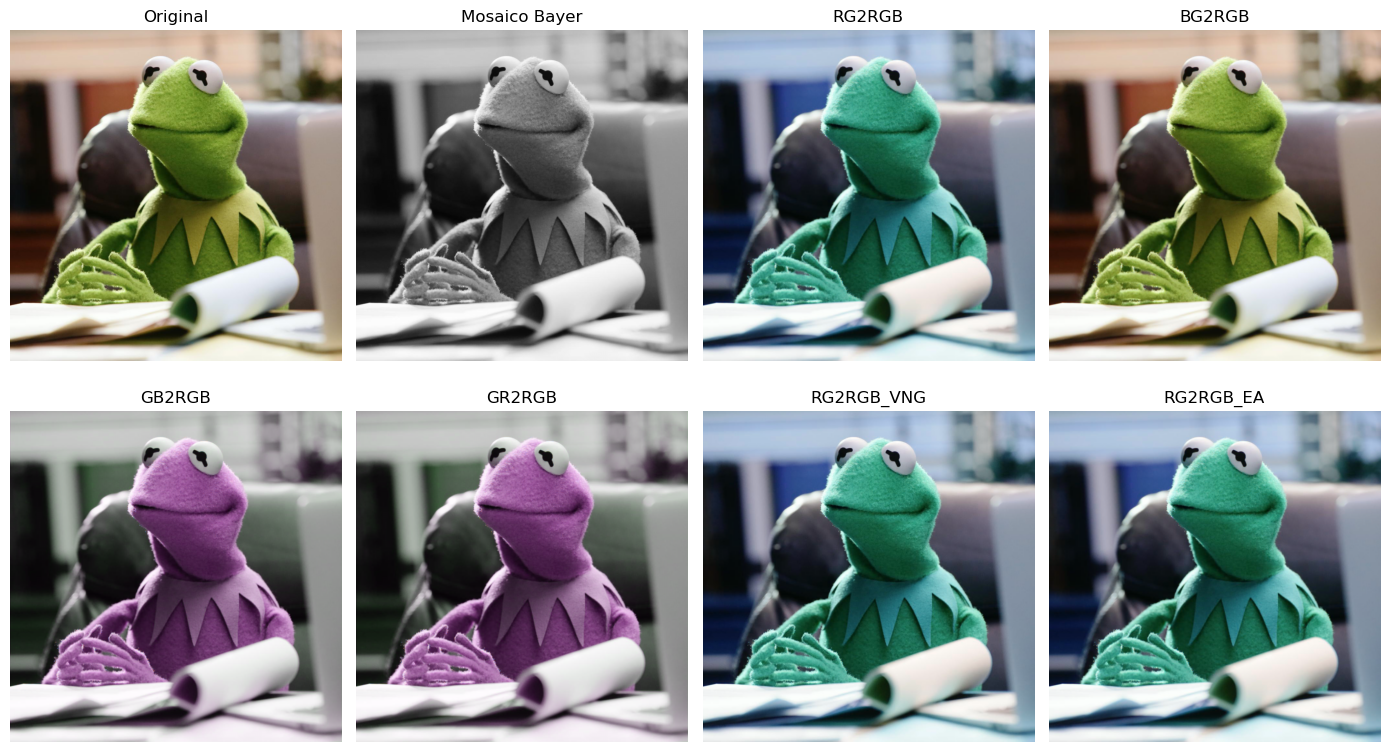

In [13]:
def crear_mosaico_bayer(img_bgr, patron='RG'):
    b, g, r = cv2.split(img_bgr)
    mosaico = np.zeros(img_bgr.shape[:2], dtype=img_bgr.dtype)

    if patron == 'RG':
        mosaico[0::2, 0::2] = r[0::2, 0::2]
        mosaico[0::2, 1::2] = g[0::2, 1::2]
        mosaico[1::2, 0::2] = g[1::2, 0::2]
        mosaico[1::2, 1::2] = b[1::2, 1::2]
    elif patron == 'BG':
        mosaico[0::2, 0::2] = b[0::2, 0::2]
        mosaico[0::2, 1::2] = g[0::2, 1::2]
        mosaico[1::2, 0::2] = g[1::2, 0::2]
        mosaico[1::2, 1::2] = r[1::2, 1::2]
    elif patron == 'GB':
        mosaico[0::2, 0::2] = g[0::2, 0::2]
        mosaico[0::2, 1::2] = b[0::2, 1::2]
        mosaico[1::2, 0::2] = r[1::2, 0::2]
        mosaico[1::2, 1::2] = g[1::2, 1::2]
    elif patron == 'GR':
        mosaico[0::2, 0::2] = g[0::2, 0::2]
        mosaico[0::2, 1::2] = r[0::2, 1::2]
        mosaico[1::2, 0::2] = b[1::2, 0::2]
        mosaico[1::2, 1::2] = g[1::2, 1::2]

    return mosaico

mosaico_rg = crear_mosaico_bayer(imagen_bgr, 'RG')

conversiones = {
    'RG2RGB': cv2.COLOR_BayerRG2RGB,
    'BG2RGB': cv2.COLOR_BayerBG2RGB,
    'GB2RGB': cv2.COLOR_BayerGB2RGB,
    'GR2RGB': cv2.COLOR_BayerGR2RGB,
    'RG2RGB_VNG': cv2.COLOR_BayerRG2RGB_VNG,
    'RG2RGB_EA': cv2.COLOR_BayerRG2RGB_EA,
}

plt.figure(figsize=(14, 8))
plt.subplot(2, 4, 1)
plt.imshow(imagen_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(mosaico_rg, cmap='gray')
plt.title('Mosaico Bayer')
plt.axis('off')

for i, (nombre, codigo) in enumerate(conversiones.items(), start=3):
    reconstruida = cv2.cvtColor(mosaico_rg, codigo)
    plt.subplot(2, 4, i)
    plt.imshow(reconstruida)
    plt.title(nombre)
    plt.axis('off')

plt.tight_layout()
plt.show()

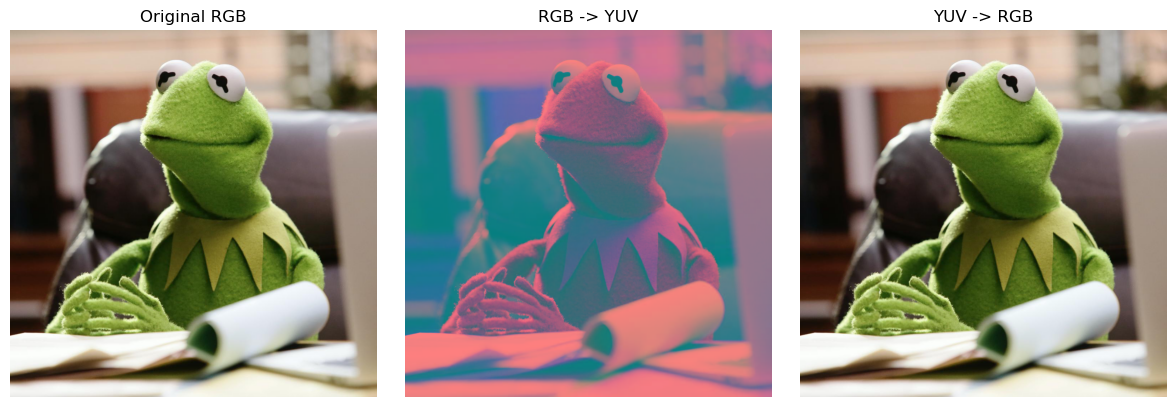

MAE RGB -> YUV -> RGB: 0.2954


In [9]:
rgb = imagen_rgb.copy()

yuv = cv2.cvtColor(rgb, cv2.COLOR_RGB2YUV)
rgb_recuperada = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(yuv)
plt.title('RGB -> YUV')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(rgb_recuperada)
plt.title('YUV -> RGB')
plt.axis('off')

plt.tight_layout()
plt.show()

mae = np.mean(np.abs(rgb.astype(np.int16) - rgb_recuperada.astype(np.int16)))
print(f'MAE RGB -> YUV -> RGB: {mae:.4f}')